In [1]:
import os
import sys
import copy
import importlib
import numpy as np
import matplotlib.pyplot as plt

SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.path.dirname(os.getcwd()))))
sys.path.append(SCRIPT_DIR)

import gwfast.gwfastGlobals as glob
import gwfast.waveforms as waveforms
import gwfast.signal as signal
import gwfast.network as network
import gwfast.fisherTools as fTools
import gwfast.gwfastUtils as utils

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [2]:
# importlib.reload(signal)

## Parameters, waveform, and detector setup

In [30]:
# Two events that are completely identical except in lensing parameters
events = {
    'Mc':np.array([50, 50]), 'eta':np.array([0.24, 0.24]), 'dL':np.array([0.8, 0.8]), 'theta':np.array([2.34, 2.34]), 'phi':np.array([5.43, 5.43]), 
    'iota':np.array([0.9*np.pi/2, 0.9*np.pi/2]), 'psi':np.array([1, 1]), 'tGPS':np.array([0, 0]), 'Phicoal':np.array([2.8, 2.8]), 
    'chi1z':np.array([1e-3, 1e-3]), 'chi2z':np.array([1e-3, 1e-3]), 'chi1x':np.array([0, 0]), 'chi2x':np.array([0, 0]), 'chi1y':np.array([0, 0]), 'chi2y':np.array([0, 0]), 
    'LambdaTilde':np.array([0]), 'deltaLambda':np.array([0]), 'ecc':np.array([0]), 
    'R_orbit':np.array([200, 300]), 'M_lens':np.array([10e4, 10e7]), 'src_pos':np.array([0.8, 0.8])
}

# Using TaylorF2 for now to speed things up
mywf = waveforms.TaylorF2_RestrictedPN()

In [31]:
# Overview of lensing effects
utils.lens(events)

Image 1 parameters: {'Mc': Array([49.55849329, 49.83779638], dtype=float64), 'eta': array([0.24, 0.24]), 'dL': array([0.8, 0.8]), 'theta': array([2.34, 2.34]), 'phi': array([5.43, 5.43]), 'iota': Array([1.33751633, 1.33695739], dtype=float64), 'psi': Array([1.0103211 , 1.00463125], dtype=float64), 'tGPS': array([0, 0]), 'Phicoal': Array([2.73899911, 2.77149021], dtype=float64), 'chi1z': array([0.001, 0.001]), 'chi2z': array([0.001, 0.001]), 'chi1x': array([0, 0]), 'chi2x': array([0, 0]), 'chi1y': array([0, 0]), 'chi2y': array([0, 0]), 'LambdaTilde': array([0]), 'deltaLambda': array([0]), 'ecc': array([0]), 'R_orbit': array([200, 300]), 'M_lens': array([1.e+05, 1.e+08]), 'src_pos': array([0.8, 0.8])} 
Image 2 parameters: {'Mc': Array([50.4479341 , 50.16306323], dtype=float64), 'eta': array([0.24, 0.24]), 'dL': array([0.8, 0.8]), 'theta': array([2.34, 2.34]), 'phi': array([5.43, 5.43]), 'iota': Array([1.48900615, 1.48955172], dtype=float64), 'psi': Array([0.98961004, 0.99535494], dtype=f

In [32]:
# Detector configurations
L1_conf = copy.deepcopy(glob.detectors).pop('L1')
L1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

H1_conf = copy.deepcopy(glob.detectors).pop('H1')
H1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

Virgo_conf = copy.deepcopy(glob.detectors).pop('Virgo')
Virgo_conf['psd_path'] =  os.path.join(glob.detPath, 'observing_scenarios_paper', 'avirgo_O5low_NEW.txt')

# Initialise the GWSignal objects
L1 = signal.GWSignal(mywf, psd_path=L1_conf['psd_path'], 
                        detector_shape=L1_conf['shape'], det_lat=L1_conf['lat'], 
                        det_long=L1_conf['long'], det_xax=L1_conf['xax'],
                        fmin=10
                        )
H1 = signal.GWSignal(mywf, psd_path=H1_conf['psd_path'], 
                        detector_shape=H1_conf['shape'], det_lat=H1_conf['lat'], 
                        det_long=H1_conf['long'], det_xax=H1_conf['xax'],
                        fmin=10
                        )
Virgo = signal.GWSignal(mywf, psd_path=Virgo_conf['psd_path'], 
                        detector_shape=Virgo_conf['shape'], det_lat=Virgo_conf['lat'], 
                        det_long=Virgo_conf['long'], det_xax=Virgo_conf['xax'],
                        fmin=10
                        )

mySignals = {'L1':L1, 'H1':H1, 'Virgo':Virgo}
myNet = network.DetNet(mySignals)

Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8
Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8
Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/avirgo_O5low_NEW.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8


## Strain

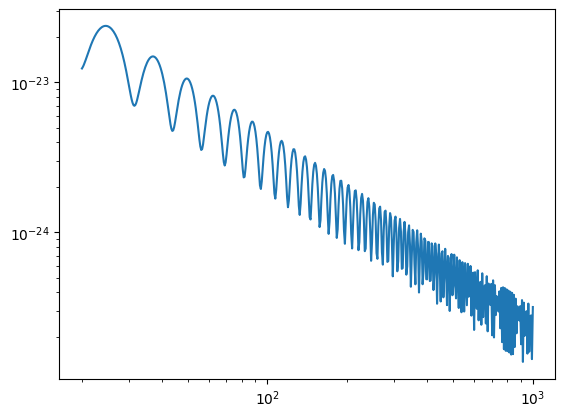

In [33]:
f_array = np.geomspace(20, 1000, num=500)
event_1_strain = L1.GWstrain(f_array, events['Mc'][0], events['eta'][0], events['dL'][0], events['theta'][0], events['phi'][0], events['iota'][0], 
                       events['psi'][0], events['tGPS'][0], events['Phicoal'][0], events['chi1z'][0], events['chi2z'][0], 
                       events['chi1x'][0], events['chi2x'][0], events['chi1y'][0], events['chi2y'][0], events['LambdaTilde'][0], events['deltaLambda'][0], events['ecc'][0], 
                       R_orbit=events['R_orbit'][0], M_lens=events['M_lens'][0], src_pos=events['src_pos'][1], use_lensing=True)

plt.loglog(f_array, np.abs(event_1_strain))

In [34]:
mySNR = myNet.SNR(events, use_lensing=True, return_all=True)
mySNR_nolens = myNet.SNR(events, return_all=True)
print("SNR with lensing:", mySNR)
print("SNR without lensing:", mySNR_nolens)

Adding tcoal from tGPS
SNR with lensing: {'L1': Array([14.4355398 , 14.55623329], dtype=float64), 'H1': Array([6.04215493, 6.09602496], dtype=float64), 'Virgo': Array([19.31978985, 19.39201652], dtype=float64), 'net': array([24.86255669, 25.00191498])}
SNR without lensing: {'L1': Array([7.2467816, 7.2467816], dtype=float64), 'H1': Array([3.05317012, 3.05317012], dtype=float64), 'Virgo': Array([9.65253476, 9.65253476], dtype=float64), 'net': array([12.4502658, 12.4502658])}


In [35]:
# Fisher matrix (3-detector network) with lensing
FisherMatrsNet = myNet.FisherMatr(events, use_lensing=True)
FisherMatrsNet

Computing Fisher for L1...
Computing derivatives...
Computing Fisher for H1...
Computing derivatives...
Computing Fisher for Virgo...
Computing derivatives...
Done.


array([[[ 1.83978075e+01,  1.67934510e+01],
        [-3.91989043e+03, -3.70647977e+03],
        [-5.10254011e+00, -5.34494572e+00],
        [ 2.36661882e+01,  2.39061273e+01],
        [-2.53948272e+01, -2.51962967e+01],
        [-2.59075741e+01, -4.04603564e+01],
        [-2.03234151e+00, -1.90677901e+00],
        [ 1.57865769e+03,  1.69000074e+03],
        [-1.00147129e+01, -1.00119378e+01],
        [-1.46252114e+03, -1.39680326e+03],
        [-9.07257732e+02, -8.68831119e+02],
        [ 4.28415756e-02,  2.51952176e-02],
        [ 3.37038012e-05, -1.23923095e-04]],

       [[-3.91989043e+03, -3.70647977e+03],
        [ 2.43692398e+06,  2.47377981e+06],
        [-4.33613604e+01, -3.18304329e+01],
        [-2.59069579e+04, -2.76452214e+04],
        [ 3.29673835e+04,  3.35830916e+04],
        [ 3.38378380e+03,  3.59162339e+03],
        [ 1.01404436e+04,  1.01612015e+04],
        [-4.16002357e+06, -4.26791308e+06],
        [ 1.16710239e+04,  1.19165755e+04],
        [ 1.11472577e+06,  1.1

In [36]:
# Fisher matrix (3-detector network) without lensing
FisherMatrsNet_nolens = myNet.FisherMatr(events)
FisherMatrsNet_nolens # the two matrices are identical as expected

Computing Fisher for L1...
Computing derivatives...
Computing Fisher for H1...
Computing derivatives...
Computing Fisher for Virgo...
Computing derivatives...
Done.


array([[[ 9.51731309e+00,  9.51731309e+00],
        [-2.08691201e+03, -2.08691201e+03],
        [-3.22935664e+00, -3.22935664e+00],
        [-1.65700428e+01, -1.65700428e+01],
        [-2.03170663e+01, -2.03170663e+01],
        [ 9.10541945e+00,  9.10541945e+00],
        [-1.83892030e+01, -1.83892030e+01],
        [ 8.87491164e+02,  8.87491164e+02],
        [-1.10991445e+01, -1.10991445e+01],
        [-7.83160887e+02, -7.83160887e+02],
        [-4.86459403e+02, -4.86459403e+02]],

       [[-2.08691201e+03, -2.08691201e+03],
        [ 1.43359364e+06,  1.43359364e+06],
        [ 3.14314776e-13,  3.14314776e-13],
        [ 3.04023403e+03,  3.04023403e+03],
        [ 2.26987972e+04,  2.26987972e+04],
        [-5.78157801e+03, -5.78157801e+03],
        [ 1.53470508e+04,  1.53470508e+04],
        [-2.50001245e+06, -2.50001245e+06],
        [ 1.41376225e+04,  1.41376225e+04],
        [ 6.60846431e+05,  6.60846431e+05],
        [ 4.31839977e+05,  4.31839977e+05]],

       [[-3.22935664e+00, -3

In [37]:
Cov, ie = fTools.CovMatr(FisherMatrsNet)
Cov_nolens, ie_nolens = fTools.CovMatr(FisherMatrsNet_nolens)
print("Inversion error with lensing:", ie)
print("Inversion error without lensing:", ie_nolens, "the two values are identical as expected")

Inversion error with lensing: [0.00089566 0.00017836]
Inversion error without lensing: [0.01867676 0.01867676] the two values are identical as expected


In [38]:
print("Covariance matrix for event 1 with lensing:", (np.diag(Cov[:,:,0])))
print("Covariance matrix for event 1 without lensing:", np.sqrt(np.diag(Cov_nolens[:,:,0])))

Covariance matrix for event 1 with lensing: [4.89321021e+02 7.87651583e+00 9.38743610e-02 1.27606625e-03
 3.07083637e-03 2.09125483e-03 1.36953141e-02 1.76329676e+00
 2.78338940e-02 9.38572769e+03 2.15551738e+04 1.47099093e+04
 8.98372838e+08]
Covariance matrix for event 1 without lensing: [3.73419748e+02 1.47548222e+02 4.97976275e+00 6.68042237e-02
 9.96231947e-02 5.65416935e-02 1.30076439e-01 2.42129082e+01
 3.49212471e+04 1.28682647e+03 3.46097109e+03]
